<a href="https://colab.research.google.com/github/adalves-ufabc/2026.Q3-PLN/blob/main/2026_Q3_PLN_AULA_03_Notebook_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Processamento de Linguagem Natural [2026-Q3]**
Prof. Alexandre Donizeti Alves

# **Extração e Pré-processamento de Dados**

---


### **Arquivo PDF**

In [ ]:
!pip install PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 16.4 MB/s eta 0:00:00


https://prograd.ufabc.edu.br/pdf/20233_MATRCULAS_DEFERIDAS_PS_AJUSTE.pdf

https://prograd.ufabc.edu.br/pdf/20233_MATRCULAS_DEFERIDAS_REAJUSTE.pdf

In [ ]:
import requests
import PyPDF2

# URL do PDF
#url = "https://prograd.ufabc.edu.br/pdf/20233_MATRCULAS_DEFERIDAS_REAJUSTE.pdf"
url = "https://prograd.ufabc.edu.br/pdf/20233_MATRCULAS_DEFERIDAS_PS_AJUSTE.pdf"

# download do PDF
response = requests.get(url)

# verificar se o download foi bem-sucedido
if response.status_code == 200:
    # criar um objeto PDF a partir do conteudo do download
    pdf_content = response.content
    pdf_file = open("ufabc_matriculas_2023_q3.pdf", "wb")
    pdf_file.write(pdf_content)
    pdf_file.close()
else:
    print("Falha ao baixar o PDF")

In [ ]:
from PyPDF2 import PdfReader

# abrir arquivo PDF em modo leitura
pdf = PdfReader('/content/ufabc_matriculas_2023_q3.pdf')

num_paginas = len(pdf.pages)

print(num_paginas)

572


In [ ]:
from PyPDF2 import PdfReader
import pandas as pd

# extrair RAs com base no codigo da turma
def extrair_ra_por_turma(pdf_path, codigo_turma):

    pdf = PdfReader(pdf_path)

    # inicializar uma lista para armazenar os RAs encontrados
    ra_lista = []

    # iterar atraves de cada pagina do PDF
    for pagina_numero in range(len(pdf.pages)):
        pagina = pdf.pages[pagina_numero]
        texto = pagina.extract_text()

        # dividir o texto em linhas
        linhas = texto.split('\n')

        # iterar atraves de cada linha para encontrar o RA com base no codigo da turma
        for linha in linhas:
            if codigo_turma in linha:
                partes = linha.split(' ')
                ra = partes[0]
                ra_lista.append(ra)

    return ra_lista

In [ ]:
pdf_path = '/content/ufabc_matriculas_2023_q3.pdf'

codigo_turma_procurado = 'NAMCZA017-13SA'

ra_encontrados = extrair_ra_por_turma(pdf_path, codigo_turma_procurado)

df = pd.DataFrame({'RA': ra_encontrados})

print(df)

             RA
0      11100816
1   11202130129
2   11201920607
3   11201811735
4   11201920328
..          ...
85  11201811594
86  11202021889
87  11201811430
88  11201811262
89  11201722180

[90 rows x 1 columns]


In [ ]:
print(df.shape)

(90, 1)


In [ ]:
!pip install openpyxl

In [ ]:
excel_arquivo_path = 'ra_' + codigo_turma_procurado + '.xlsx'

# salvar o DataFrame em uma planilha do Excel
df.to_excel(excel_arquivo_path, index=False)

print(f'A turma {codigo_turma_procurado} foi salvo em <{excel_arquivo_path}>')

A turma NAMCZA017-13SA foi salvo em <ra_NAMCZA017-13SA.xlsx>


### **Arquivo CSV**

**Passageiros do Titanic**

In [ ]:
import requests
import pandas as pd
from io import StringIO

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

resposta = requests.get(url)

if resposta.status_code == 200:
    dados = pd.read_csv(StringIO(resposta.text))

    print('Conexão bem-sucedida!')
    print(dados.head())

else:
    print('Erro:', resposta.status_code)

Conexão bem-sucedida!
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.05

In [ ]:
# Extrair nome e idade dos passageiros
passageiros = dados[['Name', 'Age']]

print(passageiros.head(10))

                                                Name   Age
0                            Braund, Mr. Owen Harris  22.0
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0
2                             Heikkinen, Miss. Laina  26.0
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0
4                           Allen, Mr. William Henry  35.0
5                                   Moran, Mr. James   NaN
6                            McCarthy, Mr. Timothy J  54.0
7                     Palsson, Master. Gosta Leonard   2.0
8  Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)  27.0
9                Nasser, Mrs. Nicholas (Adele Achem)  14.0


In [ ]:
# Extrair apenas passageiros com mais de 60 anos
idosos = dados[dados['Age'] > 60]

print(idosos[['Name', 'Age', 'Survived']])

                                          Name   Age  Survived
33                       Wheadon, Mr. Edward H  66.0         0
54              Ostby, Mr. Engelhart Cornelius  65.0         0
96                   Goldschmidt, Mr. George B  71.0         0
116                       Connors, Mr. Patrick  70.5         0
170                  Van der hoef, Mr. Wyckoff  61.0         0
252                  Stead, Mr. William Thomas  62.0         0
275          Andrews, Miss. Kornelia Theodosia  63.0         1
280                           Duane, Mr. Frank  65.0         0
326                  Nysveen, Mr. Johan Hansen  61.0         0
438                          Fortune, Mr. Mark  64.0         0
456                  Millet, Mr. Francis Davis  65.0         0
483                     Turkula, Mrs. (Hedwig)  63.0         1
493                    Artagaveytia, Mr. Ramon  71.0         0
545               Nicholson, Mr. Arthur Ernest  64.0         0
555                         Wright, Mr. George  62.0   

**População Mundial por País**

Esse CSV é disponibilizado diretamente pelo ***Our World in Data*** e contém dados de população por país ao longo do tempo. A fonte informa dados de 10.000 a.C. até 2023.

https://ourworldindata.org/

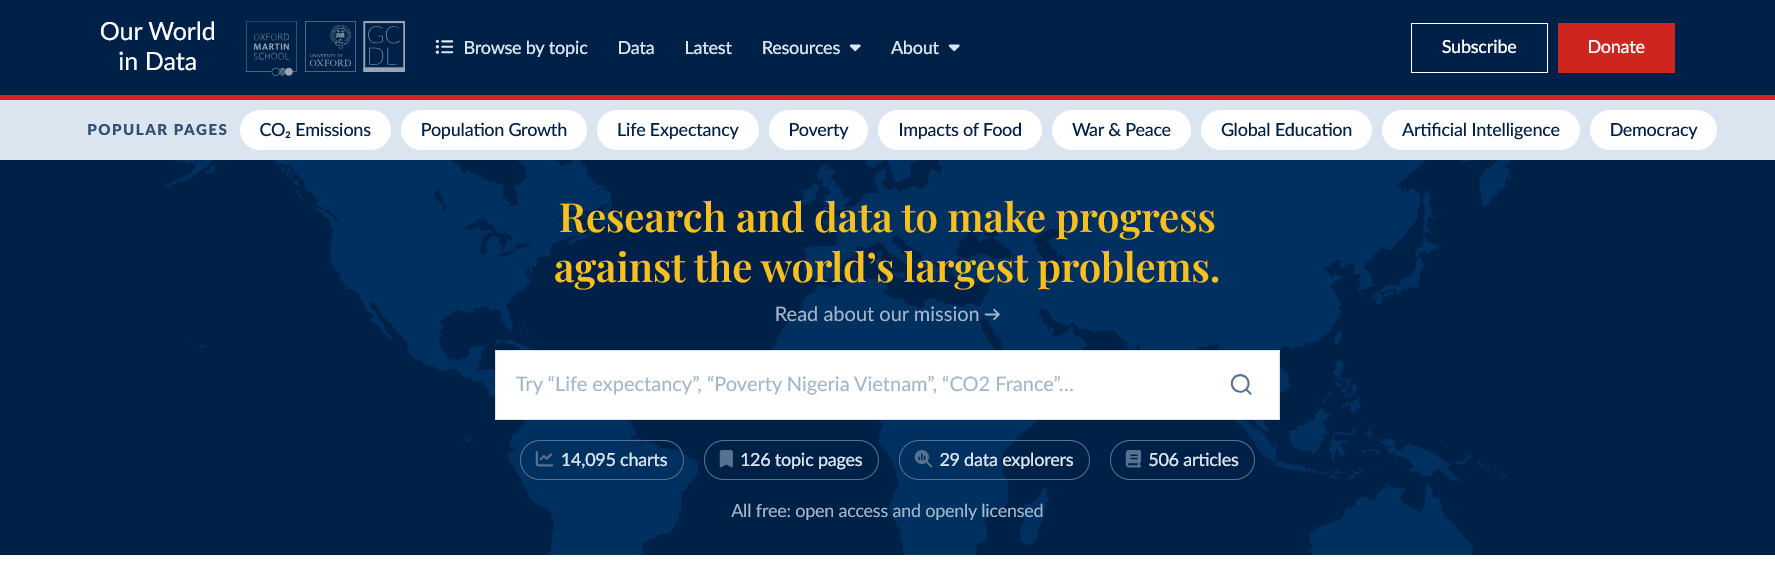

In [ ]:
import pandas as pd

url = 'https://ourworldindata.org/grapher/population.csv?v=1&csvType=full&useColumnShortNames=false'

dados = pd.read_csv(url)

# População dos países em 2023
dados_2023 = dados[dados['Year'] == 2023]

# 10 países mais populosos
print(dados_2023.sort_values('Population', ascending=False)
      [['Entity', 'Population']]
      .head(10))

                              Entity  Population
57917                          World  8091734933
3181                       Asia (UN)  4778004486
3107                            Asia  4776659631
55938  Upper-middle-income countries  3074336898
30484  Lower-middle-income countries  2869912730
595                      Africa (UN)  1480770518
521                           Africa  1479690254
24029                          India  1438069597
10781                          China  1422584930
22724          High-income countries  1416794460


In [ ]:
# Evolução da população do Brasil
brasil = dados[dados['Entity'] == 'Brazil']

print(brasil[['Year', 'Population']].tail(10))

      Year  Population
7503  2014   200085126
7504  2015   201675534
7505  2016   203218108
7506  2017   204703440
7507  2018   206107265
7508  2019   207455459
7509  2020   208660845
7510  2021   209550291
7511  2022   210306411
7512  2023   211140731


In [ ]:
# Países mais populosos em 2023
print(
    dados[dados['Year'] == 2023]
    .nlargest(10, 'Population')[['Entity', 'Population']]
)

                              Entity  Population
57917                          World  8091734933
3181                       Asia (UN)  4778004486
3107                            Asia  4776659631
55938  Upper-middle-income countries  3074336898
30484  Lower-middle-income countries  2869912730
595                      Africa (UN)  1480770518
521                           Africa  1479690254
24029                          India  1438069597
10781                          China  1422584930
22724          High-income countries  1416794460


**Avaliações de Filmes**

In [ ]:
import pandas as pd

url = 'https://tinyurl.com/moviereviewsdata'

dados = pd.read_csv(url)

print(dados[['title', 'review_text']].head())

                title                                        review_text
0    Visions of Valor  I wanted to like this movie, but it was a letd...
1  Hilarity Unleashed  Pure cinematic joy that brought tears to my eyes.
2           Soulbound  An emotional rollercoaster that left me in awe...
3       Amour Forever  A movie that failed to live up to its potentia...
4  In Search of Truth  A movie that left me uninterested and thorough...


In [ ]:
# Extrair as avaliações de filmes com nota alta
avaliacoes = dados[dados['rating'] >= 4]['review_text']

for texto in avaliacoes.head(5):
    print(texto)
    print()

Pure cinematic joy that brought tears to my eyes.

Lives up to its name. It's an enchanting story that explores the depths of human nature. The performances were exceptional.

A journey worth taking.

Incredible! I was glued to the screen from start to finish. The acting and direction are top-notch.

A tale of courage and triumph that left me breathless.



In [ ]:
# Avaliações que mencionam "love"
resultado = dados[
    dados['review_text'].str.contains('love', case=False, na=False)
]

print(resultado['review_text'].head(5).to_string(index=False))

I can't say I loved it, but I didn't hate it ei...
                         Loved every minute of it.
                  I neither loved it nor hated it.
    I didn't love it, but I didn't hate it either.
    I didn't love it, but I didn't hate it either.
